# Q6 - Frequency-domain SSI response

This notebook computes the frequency-domain response for Question 6b using the generalized SDOF reduction from the RFEM first mode and a rigid foundation with horizontal sway and rocking.

Only the ingredients needed for the calculation are kept:

- generalized structural properties from RFEM mode 1 in global $y$
- Part 2 geotechnical soil properties for the homogeneous half-space
- foundation block dimensions from the RFEM model
- dynamic soil stiffness for horizontal translation and rocking
- coupled frequency-domain solution and fixed-base comparison


## Modelling choices

The following choices are used in the calculation.

| Choice | Justification |
| --- | --- |
| Generalized SDOF from RFEM mode 1 | The frequency-domain model should represent the dominant global $y$ response without replacing the full frame by an artificial floor-lumped shear building. |
| Foundation sway and rocking | SSI produces both base shear and overturning moment, so horizontal translation alone is not sufficient. |
| Homogeneous half-space soil | The SSI guideline formulas are for a homogeneous half-space; Part 2 gives equivalent geotechnical site values. |
| $G=\rho V_s^2$ | The assignment gives $V_{s,30}=160\ \mathrm{m/s}$ and $\rho=1800\ \mathrm{kg/m^3}$, so $G=46.08\ \mathrm{MPa}$. |
| Equivalent square foundation | Table 8.1 gives compact formulas for a square surface foundation; the RFEM contact area is converted to a square with the same area. |
| Two-level mass surrogate | The first-mode ordinates are averaged over RFEM mesh nodes at each level. This is enough for a transparent first estimate, but should be replaced by a full RFEM nodal mass export if available. |
| Structural damping $\xi=5\%$ | This is consistent with the EC8 spectrum used in Q3. |
| Design input $a_g=0.504g$ | The frequency-domain analysis uses the same design PGA as Q3. |
| Symmetric foundation coupling $\tilde k_{y\theta}=0$ | For a centered square surface foundation, translational-rocking stiffness coupling is neglected. |


In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

images = Path("images")
images.mkdir(exist_ok=True)

# RFEM generalized SDOF properties, mode 1 in global Y
f1 = 6.20                         # Hz
omega1 = 2 * np.pi * f1           # rad/s
m_star = 2422.5                   # kg
m_eff_y = 8063.7                  # kg
Gamma = np.sqrt(m_eff_y / m_star)
L = Gamma * m_star                # kg
k_star = m_star * omega1**2       # N/m
xi_struct = 0.05                  # [-]
c_star = 2 * xi_struct * omega1 * m_star

# Average mode-1 uY ordinates from RFEM mesh nodes at the two levels.
mode_shape_csv = Path(r"S:\Documents\TuDelft\Q4\earthquakes\RFEM\generalized_SDof - Mode Shapes by Mesh Node.csv")
level_export_z = [-2.470, -4.940]
level_values = {z_export: [] for z_export in level_export_z}

with mode_shape_csv.open(newline="", encoding="utf-8-sig") as f:
    for row_index, row in enumerate(csv.reader(f)):
        if row_index < 2 or not row or not row[0].strip():
            continue
        mode_no = int(row[4])
        if mode_no != 1:
            continue
        z_export = float(row[3])
        uy = float(row[6])
        for z_level in level_export_z:
            if abs(z_export - z_level) < 1e-9:
                level_values[z_level].append(uy)

z1 = abs(level_export_z[0])
z2 = abs(level_export_z[1])
psi_ref_1 = float(np.mean(level_values[level_export_z[0]]))
psi_ref_2 = float(np.mean(level_values[level_export_z[1]]))
psi_ref_1_min = float(np.min(level_values[level_export_z[0]]))
psi_ref_1_max = float(np.max(level_values[level_export_z[0]]))
psi_ref_2_min = float(np.min(level_values[level_export_z[1]]))
psi_ref_2_max = float(np.max(level_values[level_export_z[1]]))
n_level_1 = len(level_values[level_export_z[0]])
n_level_2 = len(level_values[level_export_z[1]])

# Foundation block from RFEM
A_contact = 18.603                # m^2
d_found = 1.0                     # m
M_f = 46.509e3                    # kg
z_c = d_found / 2                 # m
B_eq = np.sqrt(A_contact / 4)     # half-width B for square footprint 2B x 2B
side_eq = 2 * B_eq
I_fx_centroid = M_f * (side_eq**2 + d_found**2) / 12
I_fx_contact = I_fx_centroid + M_f * z_c**2

# Part 2 geotechnical investigation
Vs = 160.0                        # m/s
rho = 1800.0                      # kg/m^3
nu = 0.33                         # [-]
N_SPT = 10.0                      # blows per 0.3 m
c_u = 50e3                        # Pa
G = rho * Vs**2                   # Pa
Vp = Vs * np.sqrt(2 * (1 - nu) / (1 - 2 * nu))

# Part 2 / Q3 design PGA
C_digit = 1
gamma_I = 1.4
g = 9.81
agR_g = 0.35 + 0.01 * C_digit
ag_design_g = gamma_I * agR_g
ag_design = ag_design_g * g

print(f"f1 = {f1:.3f} Hz, omega1 = {omega1:.3f} rad/s")
print(f"m* = {m_star:.1f} kg, L = {L:.1f} kg, k* = {k_star:.3e} N/m")
print(f"xi = {xi_struct:.3f}, c* = {c_star:.3e} Ns/m")
print(f"Foundation area = {A_contact:.3f} m^2, equivalent square side = {side_eq:.3f} m")
print(f"Mode-1 average uY, level 1: z = {z1:.3f} m, psi = {psi_ref_1:.5f}, n = {n_level_1}")
print(f"Mode-1 average uY, level 2: z = {z2:.3f} m, psi = {psi_ref_2:.5f}, n = {n_level_2}")
print(f"Vs = {Vs:.1f} m/s, rho = {rho:.1f} kg/m^3, nu = {nu:.2f}, G = {G/1e6:.2f} MPa")
print(f"Reference PGA agR = {agR_g:.3f} g")
print(f"Importance factor gamma_I = {gamma_I:.3f}")
print(f"Design PGA = gamma_I * agR = {ag_design_g:.3f} g = {ag_design:.3f} m/s^2")


f1 = 6.200 Hz, omega1 = 38.956 rad/s
m* = 2422.5 kg, L = 4419.8 kg, k* = 3.676e+06 N/m
xi = 0.050, c* = 9.437e+03 Ns/m
Foundation area = 18.603 m^2, equivalent square side = 4.313 m
Mode-1 average uY, level 1: z = 2.470 m, psi = 0.42672, n = 111
Mode-1 average uY, level 2: z = 4.940 m, psi = 0.65253, n = 111
Vs = 160.0 m/s, rho = 1800.0 kg/m^3, nu = 0.33, G = 46.08 MPa
Reference PGA agR = 0.360 g
Importance factor gamma_I = 1.400
Design PGA = gamma_I * agR = 0.504 g = 4.944 m/s^2


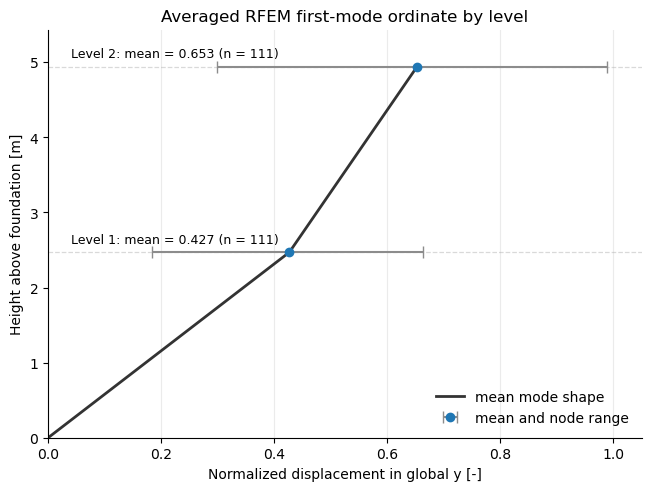

In [2]:
# Plot the averaged first-mode shape ordinates used in the generalized SDOF reduction.
z_mode = np.array([0.0, z1, z2])
psi_mode = np.array([0.0, psi_ref_1, psi_ref_2])
level_z = np.array([z1, z2])
level_mean = np.array([psi_ref_1, psi_ref_2])
level_min = np.array([psi_ref_1_min, psi_ref_2_min])
level_max = np.array([psi_ref_1_max, psi_ref_2_max])
xerr = np.vstack([level_mean - level_min, level_max - level_mean])

fig, ax = plt.subplots(figsize=(6.4, 4.8), constrained_layout=True)
ax.plot(psi_mode, z_mode, color="0.20", linewidth=2.0, label="mean mode shape")
ax.errorbar(level_mean, level_z, xerr=xerr, fmt="o", color="tab:blue", ecolor="0.55", capsize=4, markersize=6, label="mean and node range")

for z_val, psi_val, n_val, label in zip(level_z, level_mean, [n_level_1, n_level_2], ["Level 1", "Level 2"]):
    ax.text(0.04, z_val + 0.08, f"{label}: mean = {psi_val:.3f} (n = {n_val})", fontsize=9, va="bottom")
    ax.axhline(z_val, color="0.85", linestyle="--", linewidth=0.9, zorder=0)

ax.set_xlabel("Normalized displacement in global y [-]")
ax.set_ylabel("Height above foundation [m]")
ax.set_title("Averaged RFEM first-mode ordinate by level")
ax.set_xlim(0.0, 1.05)
ax.set_ylim(0.0, z2 * 1.10)
ax.grid(True, axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")
fig.savefig(images / "part2_q6_first_mode_shape.png", dpi=220, bbox_inches="tight")
plt.show()


In [3]:
# Fit the two-level mass surrogate using the known generalized mass and load factor.
A_fit = np.array([
    [psi_ref_1**2, psi_ref_2**2],
    [psi_ref_1,    psi_ref_2],
], dtype=float)
b_fit = np.array([m_star, L], dtype=float)
m_level_1, m_level_2 = np.linalg.solve(A_fit, b_fit)

M_struct = m_level_1 + m_level_2
H = m_level_1 * psi_ref_1 * z1 + m_level_2 * psi_ref_2 * z2
S_struct = m_level_1 * z1 + m_level_2 * z2
J_struct = m_level_1 * z1**2 + m_level_2 * z2**2

M_r = M_struct + M_f
S = S_struct + M_f * z_c
J = J_struct + I_fx_contact

print("Two-level surrogate mass properties:")
print(f"m_level_1 = {m_level_1:.1f} kg at z = {z1:.2f} m")
print(f"m_level_2 = {m_level_2:.1f} kg at z = {z2:.2f} m")
print(f"H = {H:.1f} kg m, M_r = {M_r:.1f} kg, S = {S:.1f} kg m, J = {J:.1f} kg m^2")


Two-level surrogate mass properties:
m_level_1 = 4789.7 kg at z = 2.47 m
m_level_2 = 3641.0 kg at z = 4.94 m
H = 16785.3 kg m, M_r = 54939.8 kg, S = 53071.9 kg m, J = 205679.8 kg m^2


## Coupled frequency-domain system

The unknowns are the generalized structural deformation, the additional SSI translation, and the additional SSI rocking:

$$
\mathbf X(\omega)=
\begin{bmatrix}
Q(\omega) & U_l(\omega) & \Theta_l(\omega)
\end{bmatrix}^T.
$$

Following the lecture notation, $U_l$ and $\Theta_l$ are additional motions caused by SSI. The known input is the free-field ground acceleration $\tilde a_g(\omega)$.

After substituting the soil interface force and moment through the dynamic stiffness matrix, the system is

$$
\left[
\begin{array}{ccc}
k^*+i\omega c^* - \omega^2m^* & -\omega^2L & -\omega^2H \\
-\omega^2L & \tilde k_{yy}-\omega^2M_r & \tilde k_{y\theta}-\omega^2S \\
-\omega^2H & \tilde k_{\theta y}-\omega^2S & \tilde k_{\theta\theta}-\omega^2J
\end{array}
\right]
\mathbf X
= -\tilde a_g
\begin{bmatrix}
L \\
M_r \\
S
\end{bmatrix}.
$$

This is the lecture system generalized from a single top mass to a modal structural coordinate. For the centered square foundation, $\tilde k_{y\theta}=\tilde k_{\theta y}=0$.


In [4]:
# Static stiffnesses from Table 8.1 for a square surface foundation.
K_y = 9 * G * B_eq / (2 - nu)
K_rx = 3.6 * G * B_eq**3 / (1 - nu)

# Radiation dashpots from Table 8.1 dimensional forms.
# The chart multipliers are taken as 1.0 because the charts are not digitized.
A_b = A_contact
I_bx = side_eq**4 / 12
C_y = rho * Vs * A_b
C_rx = rho * Vp * I_bx

def soil_dynamic_stiffness(omega):
    a0 = omega * B_eq / Vs
    ky = np.ones_like(omega)
    krx = np.maximum(1.0 - 0.20 * a0, 0.20)
    k_yy = K_y * ky + 1j * omega * C_y
    k_tt = K_rx * krx + 1j * omega * C_rx
    k_yt = np.zeros_like(omega, dtype=complex)
    k_ty = np.zeros_like(omega, dtype=complex)
    return k_yy, k_yt, k_ty, k_tt

print("Soil-foundation impedance terms:")
print(f"K_y = {K_y:.3e} N/m")
print(f"K_rx = {K_rx:.3e} N m/rad")
print(f"C_y = {C_y:.3e} Ns/m")
print(f"C_rx = {C_rx:.3e} Nms/rad")


Soil-foundation impedance terms:
K_y = 5.355e+08 N/m
K_rx = 2.483e+09 N m/rad
C_y = 5.358e+06 Ns/m
C_rx = 1.649e+07 Nms/rad


In [5]:
freq_hz = np.linspace(0.05, 25.0, 2500)
omega = 2 * np.pi * freq_hz
k_yy, k_yt, k_ty, k_tt = soil_dynamic_stiffness(omega)

Q = np.zeros_like(omega, dtype=complex)
U_l = np.zeros_like(omega, dtype=complex)
Theta_l = np.zeros_like(omega, dtype=complex)
Q_fixed = np.zeros_like(omega, dtype=complex)

for i, w in enumerate(omega):
    A = np.array([
        [k_star + 1j * w * c_star - w**2 * m_star, -w**2 * L,             -w**2 * H],
        [-w**2 * L,                                  k_yy[i] - w**2 * M_r, k_yt[i] - w**2 * S],
        [-w**2 * H,                                  k_ty[i] - w**2 * S,   k_tt[i] - w**2 * J],
    ], dtype=complex)
    b = -ag_design * np.array([L, M_r, S], dtype=complex)
    Q[i], U_l[i], Theta_l[i] = np.linalg.solve(A, b)

    A_fixed = k_star + 1j * w * c_star - w**2 * m_star
    Q_fixed[i] = (-L * ag_design) / A_fixed

U_g = -ag_design / omega**2

U_rel_1 = psi_ref_1 * Q + U_l + z1 * Theta_l
U_rel_2 = psi_ref_2 * Q + U_l + z2 * Theta_l
U_abs_1 = U_g + U_rel_1
U_abs_2 = U_g + U_rel_2

U_rel_1_fixed = psi_ref_1 * Q_fixed
U_rel_2_fixed = psi_ref_2 * Q_fixed
U_abs_1_fixed = U_g + U_rel_1_fixed
U_abs_2_fixed = U_g + U_rel_2_fixed

A_abs_2 = -omega**2 * U_abs_2
A_abs_2_fixed = -omega**2 * U_abs_2_fixed

peak_fixed = np.argmax(np.abs(A_abs_2_fixed / ag_design))
peak_ssi = np.argmax(np.abs(A_abs_2 / ag_design))

print("Peak response at reference level 2:")
print(f"Fixed-base acceleration amplification = {np.abs(A_abs_2_fixed[peak_fixed] / ag_design):.3f} at {freq_hz[peak_fixed]:.3f} Hz")
print(f"SSI acceleration amplification        = {np.abs(A_abs_2[peak_ssi] / ag_design):.3f} at {freq_hz[peak_ssi]:.3f} Hz")
print(f"Fixed-base max relative displacement  = {1e3*np.max(np.abs(U_rel_2_fixed)):.3f} mm")
print(f"SSI max relative displacement         = {1e3*np.max(np.abs(U_rel_2)):.3f} mm")


Peak response at reference level 2:
Fixed-base acceleration amplification = 11.954 at 6.190 Hz
SSI acceleration amplification        = 12.095 at 5.881 Hz
Fixed-base max relative displacement  = 38.832 mm
SSI max relative displacement         = 43.693 mm


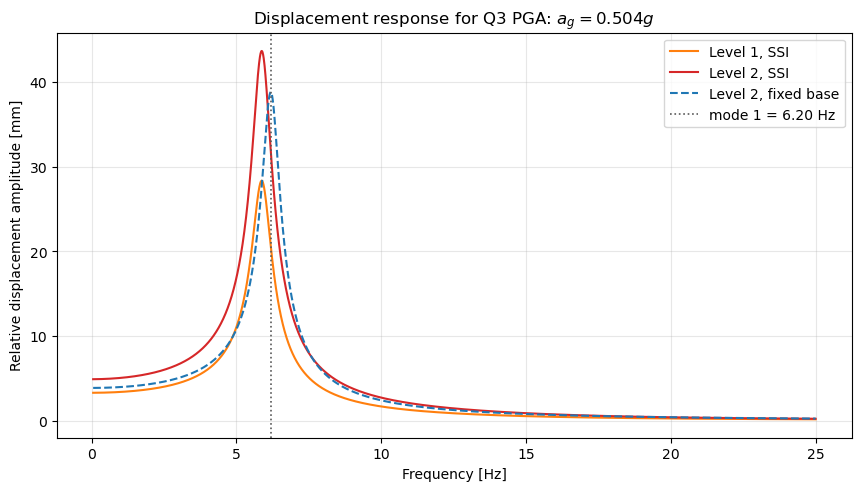

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)

ax.plot(freq_hz, np.abs(U_rel_1) * 1e3, label="Level 1, SSI", color="tab:orange")
ax.plot(freq_hz, np.abs(U_rel_2) * 1e3, label="Level 2, SSI", color="tab:red")
ax.plot(freq_hz, np.abs(U_rel_2_fixed) * 1e3, label="Level 2, fixed base", color="tab:blue", linestyle="--")
ax.axvline(f1, color="0.35", linestyle=":", linewidth=1.2, label=f"mode 1 = {f1:.2f} Hz")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Relative displacement amplitude [mm]")
ax.set_title(fr"Displacement response for Q3 PGA: $a_g={ag_design_g:.3f}g$")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(images / "part2_q6_pga_displacement_response.png", dpi=200, bbox_inches="tight")
plt.show()


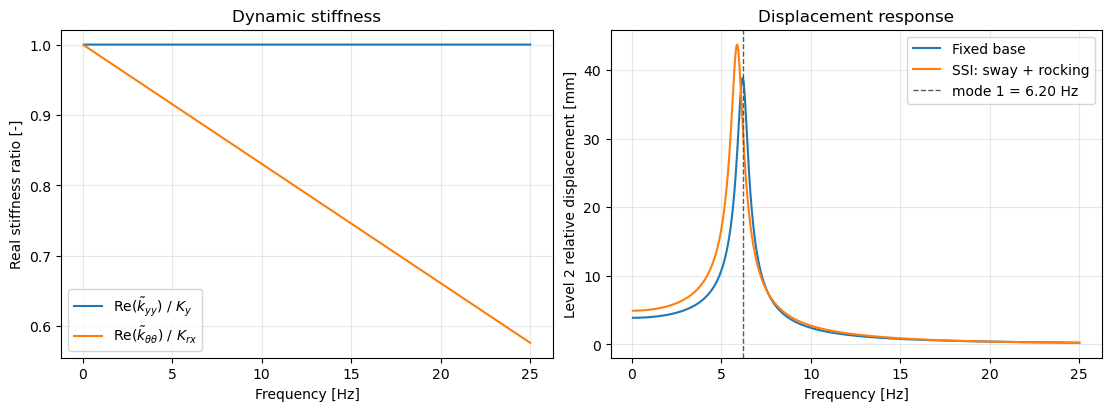

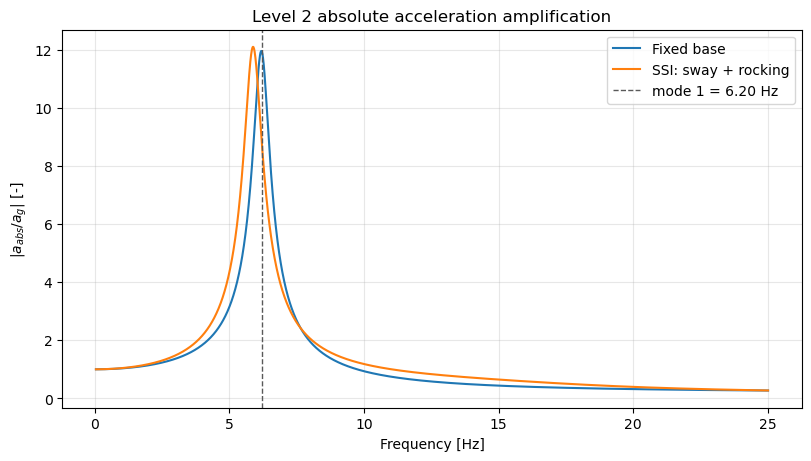

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax[0].plot(freq_hz, np.real(k_yy) / K_y, label=r"Re($\tilde{k}_{yy}$) / $K_y$")
ax[0].plot(freq_hz, np.real(k_tt) / K_rx, label=r"Re($\tilde{k}_{\theta\theta}$) / $K_{rx}$")
ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel("Real stiffness ratio [-]")
ax[0].set_title("Dynamic stiffness")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(freq_hz, np.abs(U_rel_2_fixed) * 1e3, label="Fixed base")
ax[1].plot(freq_hz, np.abs(U_rel_2) * 1e3, label="SSI: sway + rocking")
ax[1].axvline(f1, color="0.35", linestyle="--", linewidth=1.0, label=f"mode 1 = {f1:.2f} Hz")
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel("Level 2 relative displacement [mm]")
ax[1].set_title("Displacement response")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

fig.savefig(images / "part2_q6_soil_stiffness_and_displacement.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
ax.plot(freq_hz, np.abs(A_abs_2_fixed / ag_design), label="Fixed base")
ax.plot(freq_hz, np.abs(A_abs_2 / ag_design), label="SSI: sway + rocking")
ax.axvline(f1, color="0.35", linestyle="--", linewidth=1.0, label=f"mode 1 = {f1:.2f} Hz")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"$|a_{abs}/a_g|$ [-]")
ax.set_title("Level 2 absolute acceleration amplification")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(images / "part2_q6_acceleration_amplification.png", dpi=200, bbox_inches="tight")
plt.show()


## Interpretation

The SSI model introduces foundation translation and rocking in addition to the structural modal deformation. This generally shifts the coupled response away from the fixed-base frequency and changes the peak amplitude because the foundation compliance adds flexibility and radiation damping.

The present result is suitable as a first frequency-domain comparison with the fixed-base model. The two main limitations are deliberate and transparent: the missing RFEM nodal mass export is replaced by a two-level surrogate, and the SSI chart multipliers are approximated because the charts have not been digitized.
